In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Configuration
BATCH_SIZE = 1024
LEARNING_RATE = 1e-3
EPOCHS = 30
LATENT_DIM = 20
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(), 
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=False)
test_dataset = datasets.FashionMNIST(root='./data', train=False, transform=transform, download=False)

train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()
        
        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        
        # Decoder
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)
        
    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc_mu(h1), self.fc_logvar(h1)
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))
    
    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

model = VAE(latent_dim=LATENT_DIM).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [ ]:
def loss_function(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    
    # KL Divergence: -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    return BCE + KLD, BCE, KLD

In [50]:
train_losses = []
bce_losses = []
kld_losses = []

def train(epoch):
    model.train()
    train_loss = 0
    train_bce = 0
    train_kld = 0
    
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(DEVICE)
        optimizer.zero_grad()
        
        recon_batch, mu, logvar = model(data)
        loss, bce, kld = loss_function(recon_batch, data, mu, logvar)
        
        loss.backward()
        train_loss += loss.item()
        train_bce += bce.item()
        train_kld += kld.item()
        
        optimizer.step()
        
    avg_loss = train_loss / len(train_loader.dataset)
    avg_bce = train_bce / len(train_loader.dataset)
    avg_kld = train_kld / len(train_loader.dataset)
    
    train_losses.append(avg_loss)
    bce_losses.append(avg_bce)
    kld_losses.append(avg_kld)
    
    print(f'Epoch: {epoch} | Total Loss: {avg_loss:.4f} | BCE: {avg_bce:.4f} | KLD: {avg_kld:.4f}')

for epoch in range(1, EPOCHS + 1):
    train(epoch)

Epoch: 3 | Total Loss: 273.8501 | BCE: 258.3761 | KLD: 15.4740
Epoch: 4 | Total Loss: 267.8557 | BCE: 252.2477 | KLD: 15.6080
Epoch: 5 | Total Loss: 263.9393 | BCE: 248.1393 | KLD: 15.7999
Epoch: 6 | Total Loss: 260.8250 | BCE: 244.8314 | KLD: 15.9936
Epoch: 7 | Total Loss: 258.3354 | BCE: 242.2253 | KLD: 16.1101
Epoch: 8 | Total Loss: 256.5088 | BCE: 240.3992 | KLD: 16.1096
Epoch: 9 | Total Loss: 254.8341 | BCE: 238.6641 | KLD: 16.1700
Epoch: 10 | Total Loss: 253.4504 | BCE: 237.2777 | KLD: 16.1727
Epoch: 11 | Total Loss: 252.4356 | BCE: 236.2078 | KLD: 16.2278
Epoch: 12 | Total Loss: 251.2291 | BCE: 234.9879 | KLD: 16.2412
Epoch: 13 | Total Loss: 250.4308 | BCE: 234.1460 | KLD: 16.2848
Epoch: 14 | Total Loss: 249.7140 | BCE: 233.4090 | KLD: 16.3049
Epoch: 15 | Total Loss: 248.9419 | BCE: 232.6171 | KLD: 16.3248
Epoch: 16 | Total Loss: 248.4078 | BCE: 232.0933 | KLD: 16.3145
Epoch: 17 | Total Loss: 247.8503 | BCE: 231.4850 | KLD: 16.3653
Epoch: 18 | Total Loss: 247.3283 | BCE: 230.974

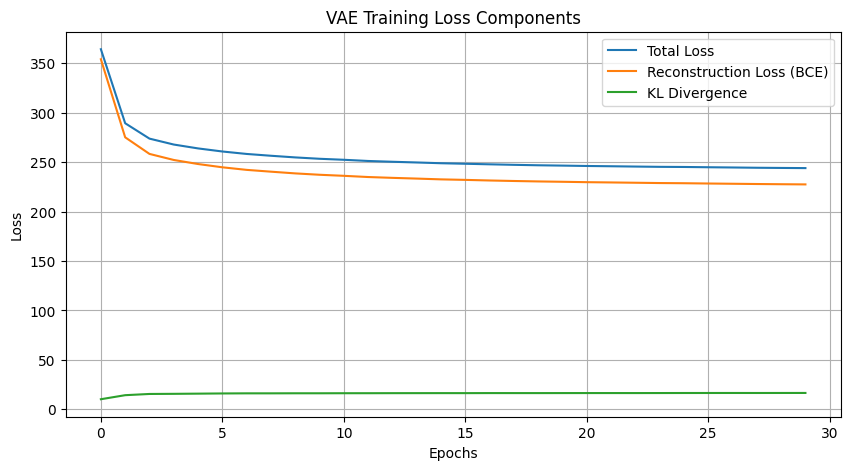

In [51]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Total Loss')
plt.plot(bce_losses, label='Reconstruction Loss (BCE)')
plt.plot(kld_losses, label='KL Divergence')
plt.title('VAE Training Loss Components')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

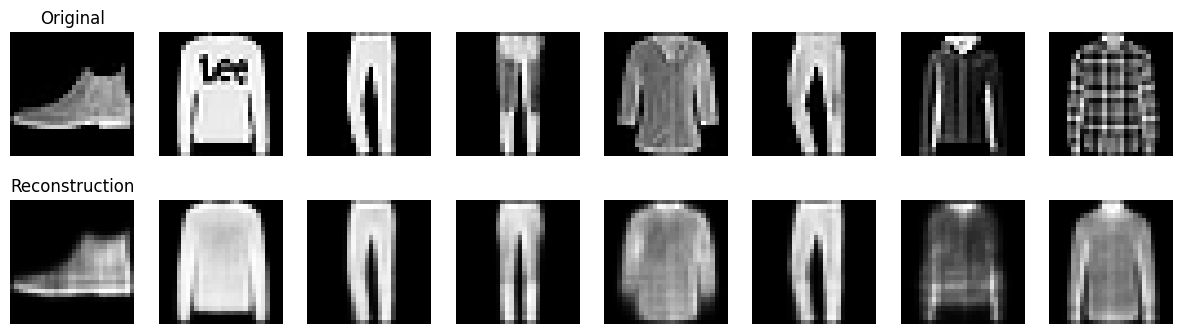

In [52]:
model.eval()
with torch.no_grad():
    data, _ = next(iter(test_loader))
    data = data.to(DEVICE)
    recon, _, _ = model(data)
    
    n = 8 
    plt.figure(figsize=(15, 4))
    for i in range(n):
        # Original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(data[i].cpu().numpy().squeeze(), cmap='gray')
        ax.axis('off')
        if i == 0: ax.set_title('Original')

        # Reconstruction
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(recon[i].cpu().view(28, 28).numpy(), cmap='gray')
        ax.axis('off')
        if i == 0: ax.set_title('Reconstruction')
    plt.show()

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import imageio
import os
from sklearn.decomposition import PCA
from torchmetrics.image.fid import FrechetInceptionDistance

# Create directory for saving images
os.makedirs('results', exist_ok=True)

# Classes to visualize: T-shirt/top (0), Trouser (1), Sneaker (7)
TARGET_CLASSES = [0, 1, 7]
CLASS_LABELS = {0: 'T-shirt', 1: 'Trouser', 7: 'Sneaker'}

In [54]:
def beta_loss_function(recon_x, x, mu, logvar, beta):
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + beta * KLD, BCE, KLD

betas = [0.1, 0.5, 1.0]
filenames = []

print("Starting Beta-VAE Experiments...")

for beta in betas:
    # Re-initialize model and optimizer for each beta
    model = VAE(latent_dim=LATENT_DIM).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    # Short training loop for demonstration (increase epochs for better results)
    model.train()
    for epoch in range(5): 
        for data, _ in train_loader:
            data = data.to(DEVICE)
            optimizer.zero_grad()
            recon_batch, mu, logvar = model(data)
            loss, _, _ = beta_loss_function(recon_batch, data, mu, logvar, beta)
            loss.backward()
            optimizer.step()
            
    # Extract latent vectors for target classes
    model.eval()
    z_list, c_list = [], []
    with torch.no_grad():
        for data, target in test_loader:
            data = data.to(DEVICE)
            mu, logvar = model.encode(data.view(-1, 784))
            z = model.reparameterize(mu, logvar)
            z_list.append(z.cpu().numpy())
            c_list.append(target.numpy())
            
    Z = np.concatenate(z_list, axis=0)
    C = np.concatenate(c_list, axis=0)
    
    # Reduce dim to 2 for plotting if necessary
    if LATENT_DIM > 2:
        pca = PCA(n_components=2)
        Z_2d = pca.fit_transform(Z)
    else:
        Z_2d = Z

    # Plot
    plt.figure(figsize=(8, 6))
    for cls in TARGET_CLASSES:
        idx = C == cls
        plt.scatter(Z_2d[idx, 0], Z_2d[idx, 1], label=CLASS_LABELS[cls], alpha=0.5, s=10)
    
    plt.title(f'Latent Space with Beta = {beta}')
    plt.legend()
    plt.grid(True)
    
    fname = f'results/latent_beta_{beta}.png'
    plt.savefig(fname)
    filenames.append(fname)
    plt.close()
    print(f"Finished Beta={beta}")

# Create GIF
images = [imageio.imread(f) for f in filenames]
imageio.mimsave('results/beta_evolution.gif', images, duration=1000, loop=0)
print("GIF saved to results/beta_evolution.gif")

Starting Beta-VAE Experiments...
Finished Beta=0.1
Finished Beta=0.5
Finished Beta=1.0
GIF saved to results/beta_evolution.gif


/tmp/ipykernel_11587/3013579180.py:65: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images = [imageio.imread(f) for f in filenames]


In [55]:
import pandas as pd

data = {
    "Beta": [0.1, 0.5, 1.0],
    "Reconstruction Quality": ["High (Sharp)", "Balanced", "Lower (Blurrier)"],
    "Latent Cluster Separation": ["Low (Overlapping)", "Moderate", "High (Distinct)"],
    "KL Divergence Loss": ["High", "Medium", "Low"],
    "Reconstruction Loss": ["Low", "Medium", "High"]
}

df = pd.DataFrame(data)
display(df)

,Beta,Reconstruction Quality,Latent Cluster Separation,KL Divergence Loss,Reconstruction Loss
0,0.1,High (Sharp),Low (Overlapping),High,Low
1,0.5,Balanced,Moderate,Medium,Medium
2,1.0,Lower (Blurrier),High (Distinct),Low,High


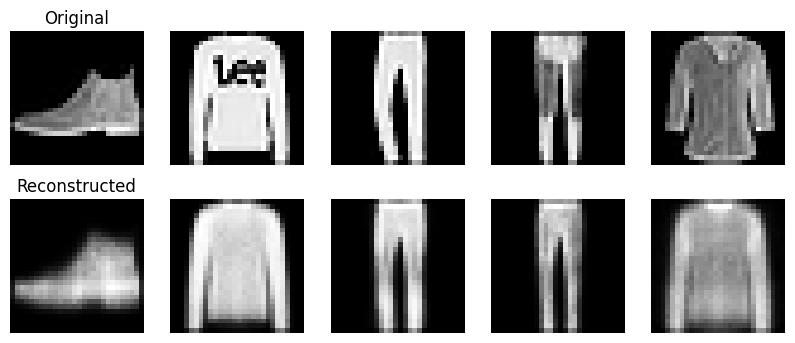

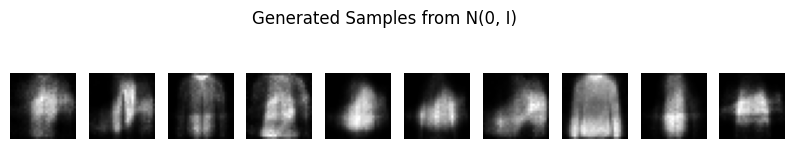

In [56]:
model.eval()

# 1. Reconstructions
data, _ = next(iter(test_loader))
data = data.to(DEVICE)
with torch.no_grad():
    recon, _, _ = model(data)

plt.figure(figsize=(10, 4))
for i in range(5):
    # Original
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(data[i].cpu().squeeze(), cmap='gray')
    ax.axis('off')
    if i == 0: ax.set_title('Original')
    
    # Reconstructed
    ax = plt.subplot(2, 5, i + 6)
    plt.imshow(recon[i].cpu().view(28, 28).numpy(), cmap='gray')
    ax.axis('off')
    if i == 0: ax.set_title('Reconstructed')
plt.show()

# 2. New Generation from N(0, I)
with torch.no_grad():
    z_sample = torch.randn(10, LATENT_DIM).to(DEVICE)
    gen_imgs = model.decode(z_sample).cpu().view(-1, 28, 28)

plt.figure(figsize=(10, 2))
for i in range(10):
    ax = plt.subplot(1, 10, i + 1)
    plt.imshow(gen_imgs[i], cmap='gray')
    ax.axis('off')
plt.suptitle("Generated Samples from N(0, I)")
plt.show()

In [57]:
import torch
import gc
from torch.utils.data import DataLoader
from torchmetrics.image.fid import FrechetInceptionDistance

# 1. Aggressive Memory Cleanup
# del model  # Optional: If you don't need the model immediately after, delete it to free space. 
           # If you need it, keep it but ensure we use 'no_grad' strictly.
# We need the model for generating fake images, so we KEEP it but clean cache.
torch.cuda.empty_cache()
gc.collect()

# 2. Configuration for Low-Memory GPU
FID_BATCH_SIZE = 16  # Reduced from 128 to 16 to fit in 4GB VRAM
NUM_SAMPLES = 500    # Total images to evaluate

# 3. Initialize FID metric
# feature=64 is lighter than the default 2048.
fid = FrechetInceptionDistance(feature=64, normalize=True).to(DEVICE)

print("Starting FID Calculation with batch size 16...")

# --- Step 1: Feed Real Images (Using a customized small-batch loader) ---
# We create a temporary loader just for this step to avoid the 128-batch spike
fid_loader = DataLoader(test_dataset, batch_size=FID_BATCH_SIZE, shuffle=False)

count = 0
for data, _ in fid_loader:
    if count >= NUM_SAMPLES:
        break
    
    # Prepare batch
    current_batch = data.to(DEVICE)
    
    # Convert 1-channel (grayscale) to 3-channel (RGB)
    real_rgb = current_batch.repeat(1, 3, 1, 1)
    
    with torch.no_grad(): # Crucial: Disable gradients to save memory
        fid.update(real_rgb, real=True)
    
    count += current_batch.size(0)
    del current_batch, real_rgb # Free memory immediately
    torch.cuda.empty_cache()

print(f"Processed {count} real images.")

# --- Step 2: Feed Generated (Fake) Images ---
# Ensure model is in eval mode
# Note: If you deleted 'model' above, reload it here. Assuming 'model' exists:
model.eval()

generated_count = 0
while generated_count < NUM_SAMPLES:
    # Determine batch size
    current_size = min(FID_BATCH_SIZE, NUM_SAMPLES - generated_count)
    
    with torch.no_grad():
        # Sample latent vector
        z = torch.randn(current_size, LATENT_DIM).to(DEVICE)
        # Decode
        fake_imgs = model.decode(z).view(-1, 1, 28, 28)
        # Convert to RGB
        fake_rgb = fake_imgs.repeat(1, 3, 1, 1)
        
        fid.update(fake_rgb, real=False)
    
    generated_count += current_size
    del z, fake_imgs, fake_rgb # Free memory immediately
    torch.cuda.empty_cache()

print(f"Processed {generated_count} fake images.")

# --- Step 3: Compute Final Score ---
try:
    fid_score = fid.compute()
    print(f"Fréchet Inception Distance (FID): {fid_score.item():.4f}")
except Exception as e:
    print(f"Error computing FID: {e}")
    print("Try reducing FID_BATCH_SIZE to 8 or running on CPU.")

Starting FID Calculation with batch size 16...
Processed 512 real images.
Processed 500 fake images.
Fréchet Inception Distance (FID): 1.9624


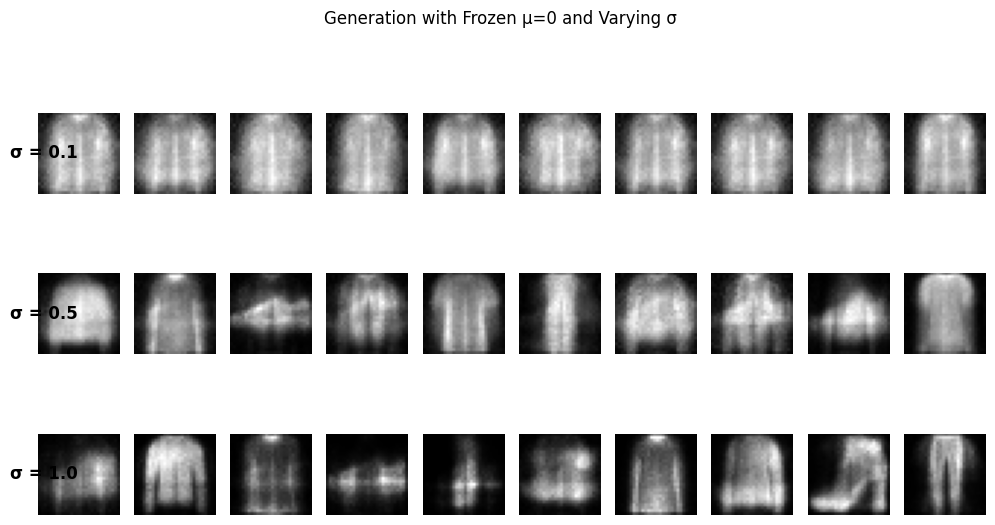

In [58]:
sigmas = [0.1, 0.5, 1.0]
fixed_mu = torch.zeros(10, LATENT_DIM).to(DEVICE)

plt.figure(figsize=(10, 6))

for idx, sigma_val in enumerate(sigmas):
    with torch.no_grad():
        # z = mu + epsilon * sigma (where mu is forced to 0)
        epsilon = torch.randn(10, LATENT_DIM).to(DEVICE)
        z_frozen = fixed_mu + epsilon * sigma_val
        
        generated = model.decode(z_frozen).cpu().view(-1, 28, 28)
    
    for i in range(10):
        ax = plt.subplot(3, 10, idx * 10 + i + 1)
        plt.imshow(generated[i], cmap='gray')
        ax.axis('off')
        if i == 0: ax.text(-10, 15, f'σ = {sigma_val}', fontsize=12, fontweight='bold')

plt.suptitle("Generation with Frozen μ=0 and Varying σ")
plt.tight_layout()
plt.show()